In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set(style="whitegrid")

In [12]:
df = pd.read_csv("data.csv")  
df.head()


,Name,Age,Height,Weight,Score
0,Alice,25,165,55,88
1,Bob,30,175,78,72
2,Charlie,28,180,85,91
3,David,35,160,70,65
4,Eva,22,170,60,95


In [13]:
print("Summary Statistics:")
display(df.describe())

# Median for each numeric column
print("\nMedian values:")
display(df.median(numeric_only=True))

# Standard deviation
print("\nStandard Deviation:")
display(df.std(numeric_only=True))

Summary Statistics:


,Age,Height,Weight,Score
count,5.000000,5.000000,5.000000,5.000000
mean,28.000000,170.000000,69.600000,82.200000
std,4.949747,7.905694,12.381438,12.988456
min,22.000000,160.000000,55.000000,65.000000
25%,25.000000,165.000000,60.000000,72.000000
50%,28.000000,170.000000,70.000000,88.000000
75%,30.000000,175.000000,78.000000,91.000000
max,35.000000,180.000000,85.000000,95.000000



Median values:


Age        28.0
Height    170.0
Weight     70.0
Score      88.0
dtype: float64


Standard Deviation:


Age        4.949747
Height     7.905694
Weight    12.381438
Score     12.988456
dtype: float64

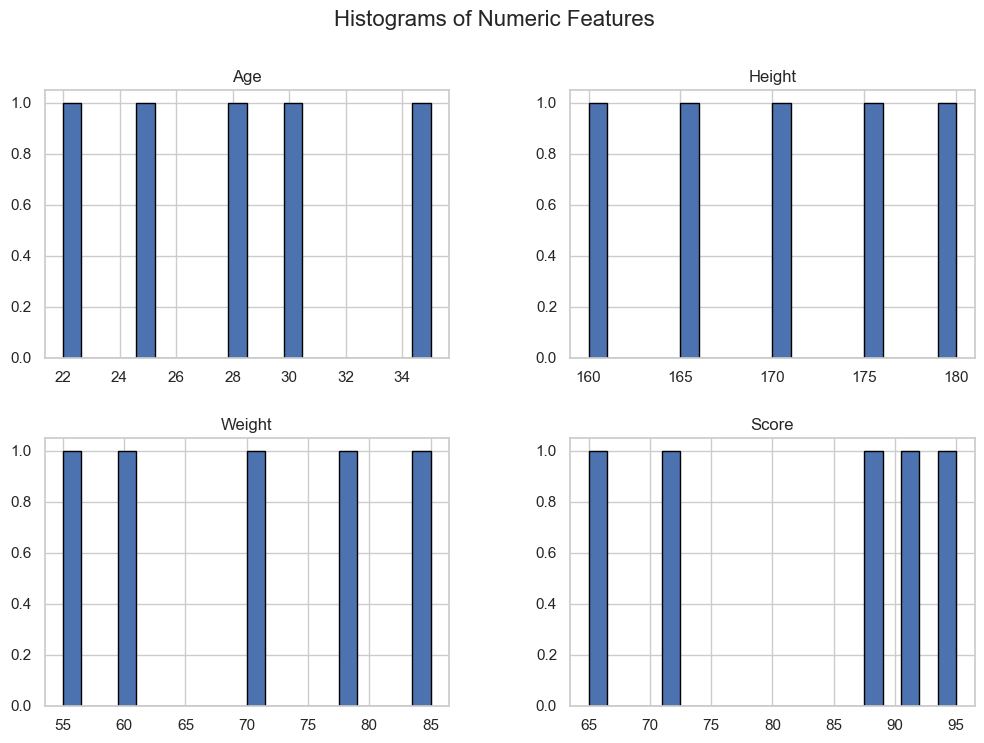

In [14]:
df.hist(bins=20, figsize=(12, 8), edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.show()

KeyError: "None of [Index([('Age', 'Height', 'Weight', 'Score')], dtype='object')] are in the [columns]"

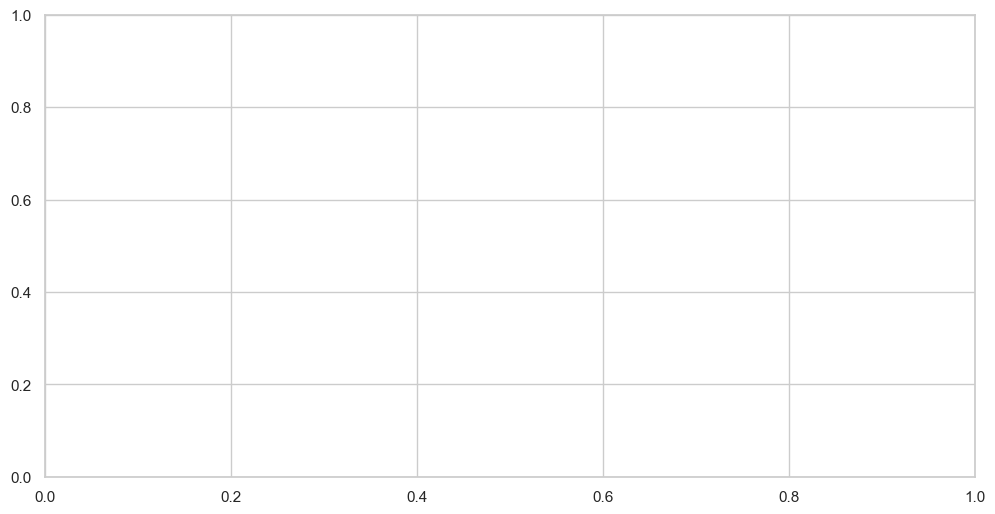

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 6))
df.boxplot(column=numeric_cols)
plt.title("Boxplots of Numeric Features", fontsize=16)
plt.xticks(rotation=45)
plt.show()


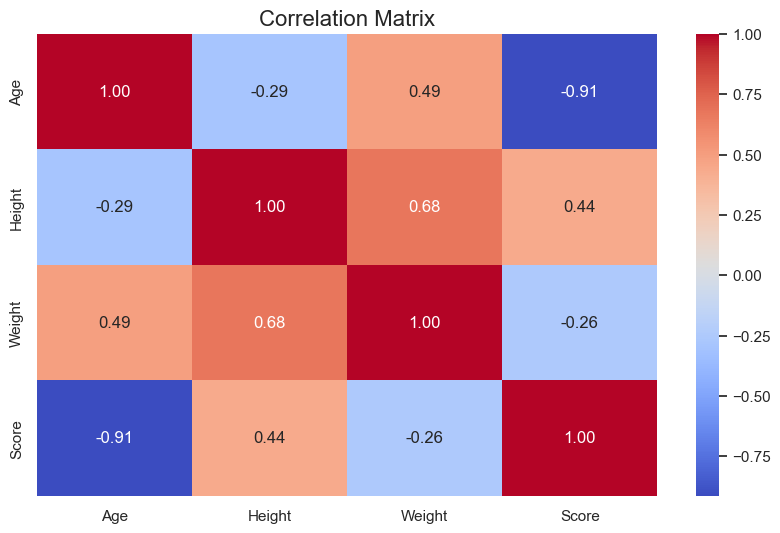

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix", fontsize=16)
plt.show()

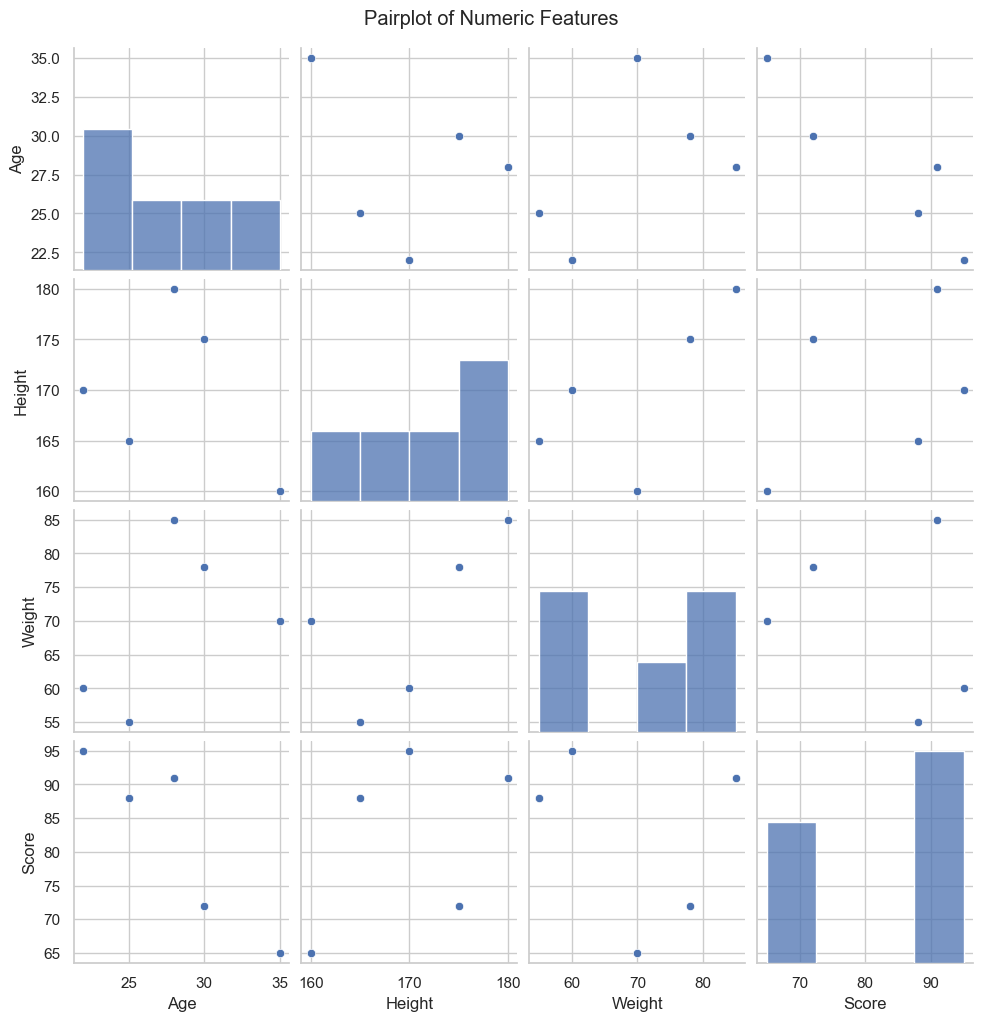

In [ ]:
sns.pairplot(df[numeric_cols])
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()



In [ ]:
high_corr = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1)]
print("Highly Correlated Features (Possible Multicollinearity):")
print(high_corr.dropna(how="all").dropna(axis=1, how="all"))

# Example: check outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if not outliers.empty:
        print(f"{col} has {len(outliers)} outliers.")


Highly Correlated Features (Possible Multicollinearity):
Empty DataFrame
Columns: []
Index: []
